In [1]:
!pip install pyarrow fastparquet xgboost lightgbm imbalanced-learn shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

path = "/content/drive/MyDrive/AI_Powered_IDS"

print(os.listdir(path))

['cic-collection.parquet']


In [4]:
import pandas as pd

file_path = "/content/drive/MyDrive/AI_Powered_IDS/cic-collection.parquet"

df = pd.read_parquet(file_path)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
print(df.shape)

print(df.columns.tolist())

print(df.head())

print(df['Label'].value_counts().head(20))

(9167581, 59)
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'URG Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Act Data Packets', 'Fwd Seg Size Mi

In [6]:
import numpy as np

# ==============================
# 1. Missing Values
# ==============================
print("Missing Values:")
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

# ==============================
# 2. Infinite Values
# ==============================
print("\nChecking Infinite Values...")

numeric_cols = df.select_dtypes(include=[np.number]).columns

inf_count = np.isinf(df[numeric_cols]).sum().sum()

print("Total Infinite Values:", inf_count)

# ==============================
# 3. Duplicate Rows
# ==============================
print("\nChecking Duplicate Rows...")

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# ==============================
# 4. Memory Usage
# ==============================
print("\nMemory Usage (GB):")

memory_usage = df.memory_usage(deep=True).sum() / 1024**3

print(round(memory_usage, 2), "GB")

Missing Values:
Series([], dtype: int64)

Checking Infinite Values...
Total Infinite Values: 0

Checking Duplicate Rows...
Duplicate Rows: 310

Memory Usage (GB):
3.57 GB


Label
Benign                  7186189
DDoS-LOIC-HTTP           575364
DoS-Hulk                 318740
DDoS-HOIC                198861
Botnet                   145968
DDoS                     128062
DDoS-NTP                 121328
DDoS-TFTP                 98833
Bruteforce-SSH            97260
Infiltration              94857
DoS-Goldeneye             52324
DDoS-Syn                  47757
DDoS-UDP                  28863
DoS-Slowloris             15243
DDoS-MSSQL                11784
DDoS-UDPLag                8452
Bruteforce-FTP             5984
DoS-Slowhttptest           5271
DDoS-Ddossim               5115
DDoS-DNS                   3668
DoS-Slowread               2786
Portscan                   2255
DDoS-LDAP                  2092
Webattack-bruteforce       2020
DDoS-SNMP                  2017
DDoS-Slowloris             1858
DoS-Slowheaders            1649
Webattack-XSS               876
DoS-Rudy                    699
DDoS-NetBIOS                675
DoS-Slowbody                621
We

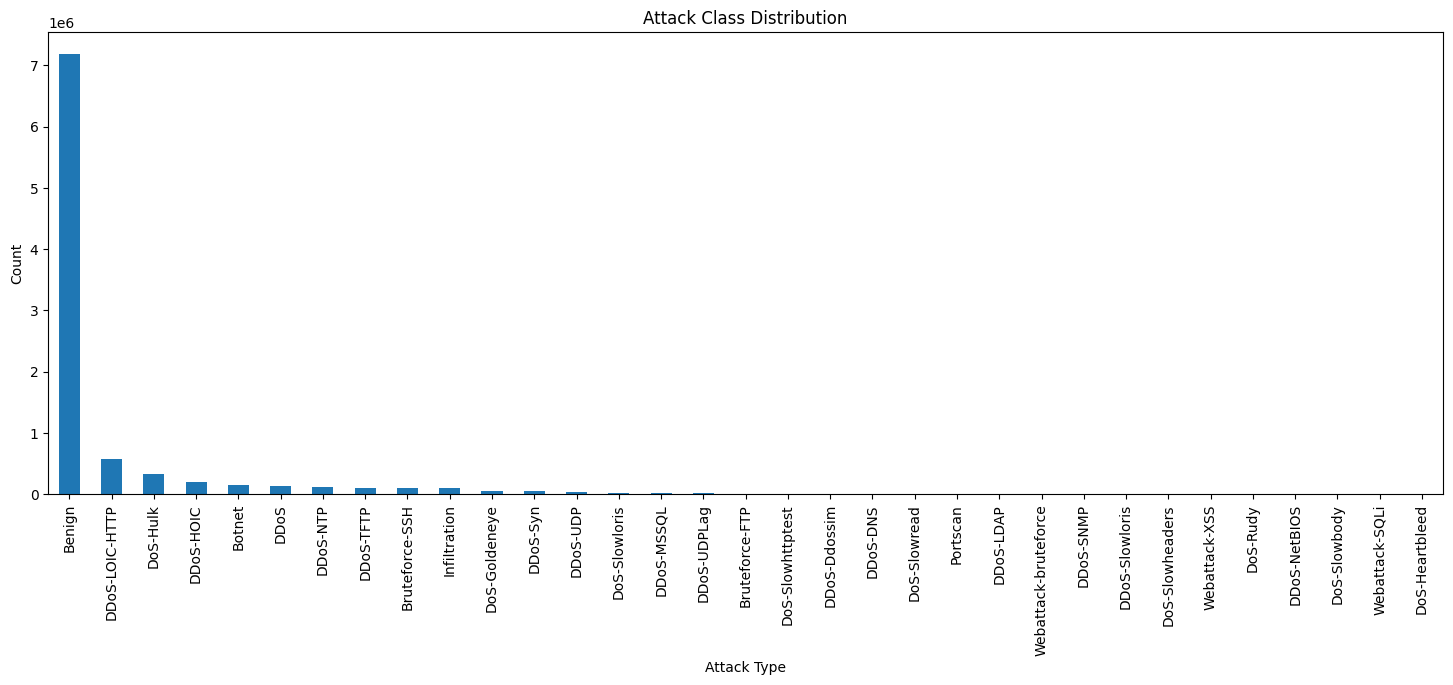

In [7]:
import matplotlib.pyplot as plt

# Top attack counts
attack_counts = df['Label'].value_counts()

print(attack_counts)

# Plot
plt.figure(figsize=(18,6))

attack_counts.plot(kind='bar')

plt.title("Attack Class Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [8]:
# Minimum samples threshold
MIN_SAMPLES = 1000

# Count labels
label_counts = df['Label'].value_counts()

# Keep only classes with enough samples
valid_labels = label_counts[label_counts >= MIN_SAMPLES].index

# Filter dataset
df_filtered = df[df['Label'].isin(valid_labels)]

# Check new distribution
print("Filtered Dataset Shape:")
print(df_filtered.shape)

print("\nRemaining Class Distribution:")
print(df_filtered['Label'].value_counts())

Filtered Dataset Shape:
(9164600, 59)

Remaining Class Distribution:
Label
Benign                  7186189
DDoS-LOIC-HTTP           575364
DoS-Hulk                 318740
DDoS-HOIC                198861
Botnet                   145968
DDoS                     128062
DDoS-NTP                 121328
DDoS-TFTP                 98833
Bruteforce-SSH            97260
Infiltration              94857
DoS-Goldeneye             52324
DDoS-Syn                  47757
DDoS-UDP                  28863
DoS-Slowloris             15243
DDoS-MSSQL                11784
DDoS-UDPLag                8452
Bruteforce-FTP             5984
DoS-Slowhttptest           5271
DDoS-Ddossim               5115
DDoS-DNS                   3668
DoS-Slowread               2786
Portscan                   2255
DDoS-LDAP                  2092
Webattack-bruteforce       2020
DDoS-SNMP                  2017
DDoS-Slowloris             1858
DoS-Slowheaders            1649
Name: count, dtype: int64


In [9]:
# Maximum samples allowed per class
MAX_SAMPLES = 50000

# Balanced sampling
balanced_df = (
    df_filtered
    .groupby('Label', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_SAMPLES), random_state=42))
)

# Shuffle dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check results
print("Balanced Dataset Shape:")
print(balanced_df.shape)

print("\nBalanced Class Distribution:")
print(balanced_df['Label'].value_counts())

/tmp/ipykernel_7257/3497041280.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_SAMPLES), random_state=42))


Balanced Dataset Shape:
(696814, 59)

Balanced Class Distribution:
Label
DDoS-NTP                50000
DoS-Goldeneye           50000
Botnet                  50000
DDoS                    50000
Infiltration            50000
DoS-Hulk                50000
DDoS-TFTP               50000
Bruteforce-SSH          50000
DDoS-HOIC               50000
Benign                  50000
DDoS-LOIC-HTTP          50000
DDoS-Syn                47757
DDoS-UDP                28863
DoS-Slowloris           15243
DDoS-MSSQL              11784
DDoS-UDPLag              8452
Bruteforce-FTP           5984
DoS-Slowhttptest         5271
DDoS-Ddossim             5115
DDoS-DNS                 3668
DoS-Slowread             2786
Portscan                 2255
DDoS-LDAP                2092
Webattack-bruteforce     2020
DDoS-SNMP                2017
DDoS-Slowloris           1858
DoS-Slowheaders          1649
Name: count, dtype: int64


In [11]:
# Check unique values in ClassLabel
print(balanced_df['ClassLabel'].value_counts())

# Compare Label vs ClassLabel
print("\nUnique Labels:")
print(balanced_df['Label'].nunique())

print("\nUnique ClassLabels:")
print(balanced_df['ClassLabel'].nunique())

ClassLabel
DDoS            361606
DoS             124949
Bruteforce       55984
Botnet           50000
Infiltration     50000
Benign           50000
Portscan          2255
Webattack         2020
Name: count, dtype: int64

Unique Labels:
27

Unique ClassLabels:
8


In [12]:
# Drop fine-grained label
balanced_df = balanced_df.drop(columns=['Label'])

# Verify
print(balanced_df.columns)

print("\nRemaining Target Column:")
print("ClassLabel")

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Fwd Packets Length Total', 'Bwd Packets Length Total',
       'Fwd Packet Length Max', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count',
       'URG Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size',
       'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
       'Subflow Bwd Packets', 'Subflow Bwd By

In [13]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
label_encoder = LabelEncoder()

# Encode target labels
balanced_df['ClassLabel'] = label_encoder.fit_transform(balanced_df['ClassLabel'])

# Show mappings
label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print("Label Encoding Mapping:")
print(label_mapping)

Label Encoding Mapping:
{'Benign': np.int64(0), 'Botnet': np.int64(1), 'Bruteforce': np.int64(2), 'DDoS': np.int64(3), 'DoS': np.int64(4), 'Infiltration': np.int64(5), 'Portscan': np.int64(6), 'Webattack': np.int64(7)}


In [14]:
# Features
X = balanced_df.drop(columns=['ClassLabel'])

# Target
y = balanced_df['ClassLabel']

# Verify shapes
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (696814, 57)
Target Shape: (696814,)


In [15]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (557451, 57)
Testing Features Shape: (139363, 57)

Training Labels Shape: (557451,)
Testing Labels Shape: (139363,)


In [16]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# Verify shapes
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Scaled Training Shape: (557451, 57)
Scaled Testing Shape: (139363, 57)


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train model
dt_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:")
print(dt_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy:
0.9687793747264338

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79     10000
           1       1.00      1.00      1.00     10000
           2       1.00      1.00      1.00     11197
           3       1.00      1.00      1.00     72321
           4       1.00      1.00      1.00     24990
           5       0.79      0.79      0.79     10000
           6       0.92      0.94      0.93       451
           7       0.98      0.96      0.97       404

    accuracy                           0.97    139363
   macro avg       0.93      0.93      0.93    139363
weighted avg       0.97      0.97      0.97    139363



In [67]:
from sklearn.metrics import roc_auc_score

# Decision Tree probabilities
y_score_dt = dt_model.predict_proba(X_test_scaled)

# ROC-AUC
dt_roc_auc = roc_auc_score(
    y_test,
    y_score_dt,
    multi_class='ovr'
)

print("Decision Tree ROC-AUC:")
print(dt_roc_auc)

Decision Tree ROC-AUC:
0.9648873917305634


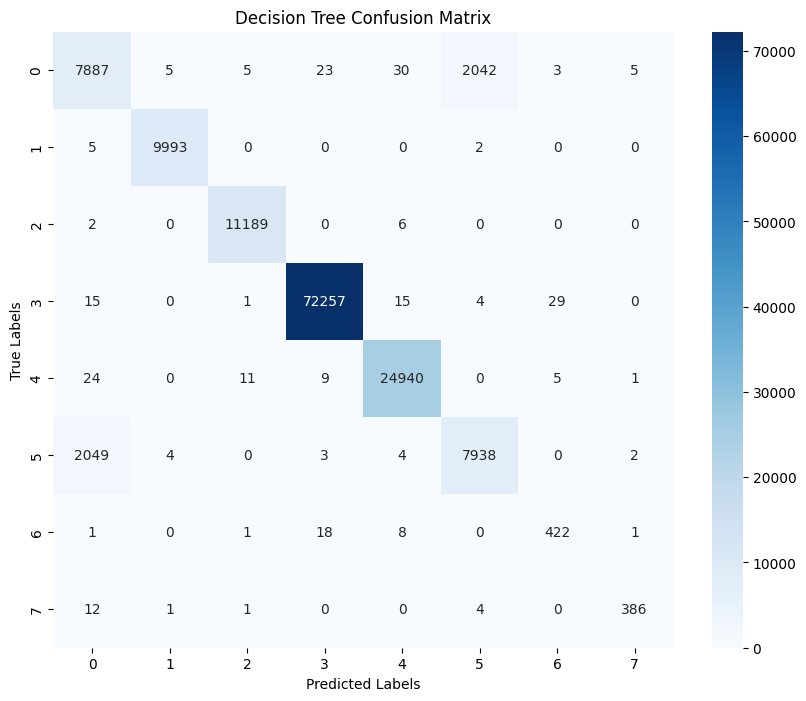

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:")
print(rf_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.9745556568099136

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82     10000
           1       1.00      1.00      1.00     10000
           2       1.00      1.00      1.00     11197
           3       1.00      1.00      1.00     72321
           4       1.00      1.00      1.00     24990
           5       0.81      0.88      0.84     10000
           6       0.96      0.93      0.95       451
           7       0.97      0.95      0.96       404

    accuracy                           0.97    139363
   macro avg       0.95      0.94      0.95    139363
weighted avg       0.97      0.97      0.97    139363



In [68]:
# Random Forest probabilities
y_score_rf = rf_model.predict_proba(X_test_scaled)

# ROC-AUC
rf_roc_auc = roc_auc_score(
    y_test,
    y_score_rf,
    multi_class='ovr'
)

print("Random Forest ROC-AUC:")
print(rf_roc_auc)

Random Forest ROC-AUC:
0.9971984717615847


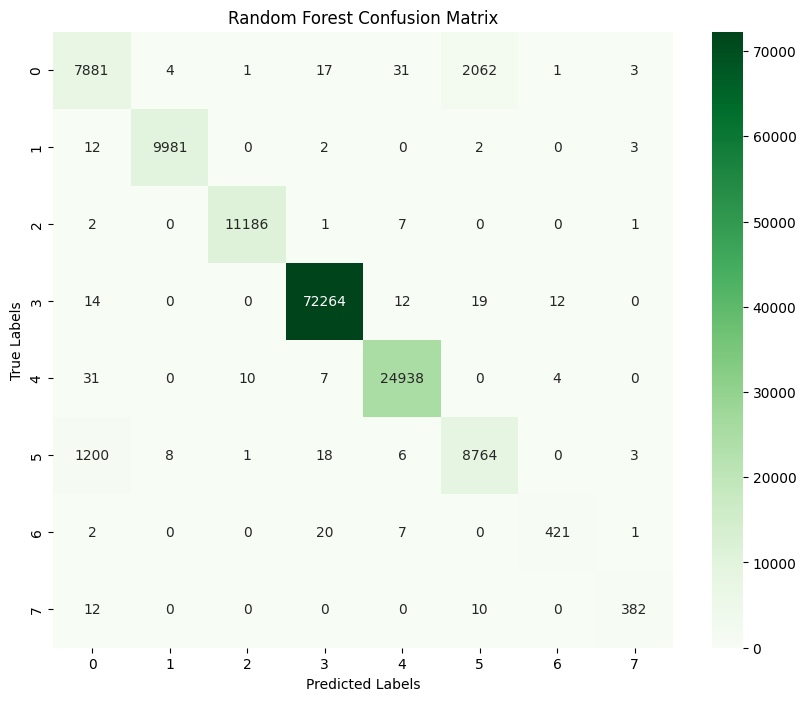

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create XGBoost model
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=8,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist'
)

# Train model
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:")
print(xgb_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy:
0.9715347689128392

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.68      0.78     10000
           1       1.00      1.00      1.00     10000
           2       1.00      1.00      1.00     11197
           3       1.00      1.00      1.00     72321
           4       1.00      1.00      1.00     24990
           5       0.75      0.94      0.83     10000
           6       0.96      0.93      0.94       451
           7       0.97      0.96      0.97       404

    accuracy                           0.97    139363
   macro avg       0.95      0.94      0.94    139363
weighted avg       0.97      0.97      0.97    139363



In [69]:
# XGBoost probabilities
y_score_xgb = xgb_model.predict_proba(X_test_scaled)

# ROC-AUC
xgb_roc_auc = roc_auc_score(
    y_test,
    y_score_xgb,
    multi_class='ovr'
)

print("XGBoost ROC-AUC:")
print(xgb_roc_auc)

XGBoost ROC-AUC:
0.9978147474785974


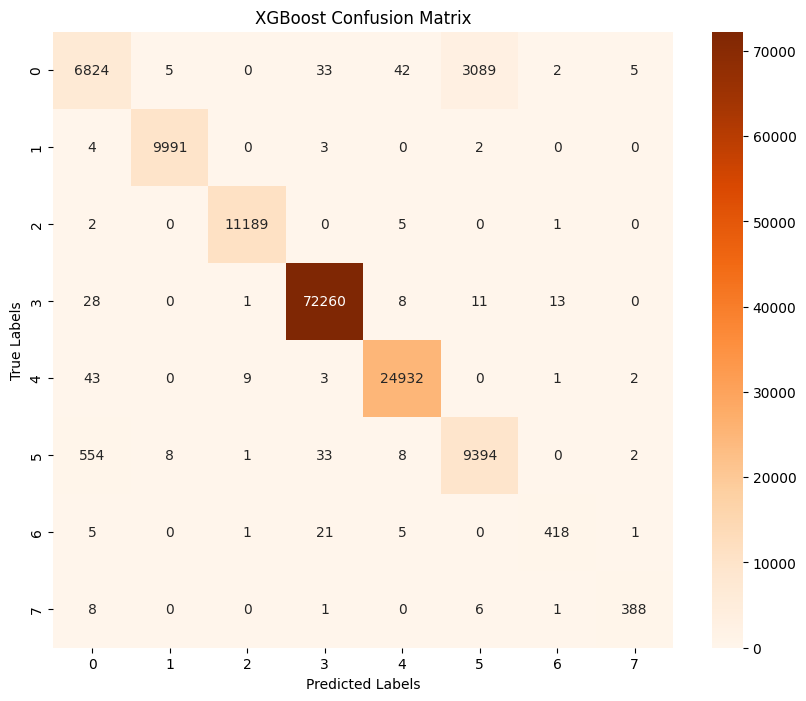

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

In [23]:
import numpy as np

# Reshape for RNN
X_train_rnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_rnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

# Verify shapes
print("RNN Training Shape:", X_train_rnn.shape)
print("RNN Testing Shape:", X_test_rnn.shape)

RNN Training Shape: (557451, 57, 1)
RNN Testing Shape: (139363, 57, 1)


In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [25]:
# One-hot encode labels
y_train_rnn = to_categorical(y_train, num_classes=8)
y_test_rnn = to_categorical(y_test, num_classes=8)

# Verify shapes
print("Encoded Training Labels Shape:", y_train_rnn.shape)
print("Encoded Testing Labels Shape:", y_test_rnn.shape)

Encoded Training Labels Shape: (557451, 8)
Encoded Testing Labels Shape: (139363, 8)


In [26]:
from tensorflow.keras.callbacks import EarlyStopping

# Build RNN model
rnn_model = Sequential([

    SimpleRNN(
        64,
        input_shape=(57, 1),
        activation='tanh'
    ),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(8, activation='softmax')
])

# Compile model
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Model summary
rnn_model.summary()

# Train model
history_rnn = rnn_model.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,568 (25.66 KB)

 Trainable params: 6,568 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8530 - loss: 0.4104 - val_accuracy: 0.8224 - val_loss: 0.4904
Epoch 2/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8976 - loss: 0.2654 - val_accuracy: 0.9229 - val_loss: 0.1885
Epoch 3/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9199 - loss: 0.2043 - val_accuracy: 0.9314 - val_loss: 0.1753
Epoch 4/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9237 - loss: 0.1941 - val_accuracy: 0.9195 - val_loss: 0.2027
Epoch 5/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9286 - loss: 0.1780 - val_accuracy: 0.9347 - val_loss: 0.1604
Epoch 6/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9298 - loss: 0.1723 - val_accuracy: 0.9303 - val_loss: 0.1763
Epoch 7/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9309 - loss: 0.1700 - val_accuracy: 0.9301 - val_loss: 0.1614
Epoch 8/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9291 - loss: 

In [27]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred_rnn_probs = rnn_model.predict(X_test_rnn)

# Convert probabilities to class labels
y_pred_rnn = np.argmax(y_pred_rnn_probs, axis=1)

# Convert one-hot encoded y_test back to labels
y_test_labels = np.argmax(y_test_rnn, axis=1)

# Accuracy
rnn_accuracy = accuracy_score(y_test_labels, y_pred_rnn)

print("RNN Accuracy:")
print(rnn_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_rnn))

4356/4356 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
RNN Accuracy:
0.9393956789104713

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.42      0.55     10000
           1       1.00      0.98      0.99     10000
           2       1.00      0.99      1.00     11197
           3       0.99      0.99      0.99     72321
           4       0.96      0.99      0.97     24990
           5       0.62      0.87      0.72     10000
           6       0.82      0.81      0.82       451
           7       0.93      0.80      0.86       404

    accuracy                           0.94    139363
   macro avg       0.89      0.86      0.86    139363
weighted avg       0.94      0.94      0.94    139363



In [70]:
# RNN ROC-AUC
rnn_roc_auc = roc_auc_score(
    y_test_rnn,
    y_pred_rnn_probs,
    multi_class='ovr'
)

print("RNN ROC-AUC:")
print(rnn_roc_auc)

RNN ROC-AUC:
0.9929969640855606


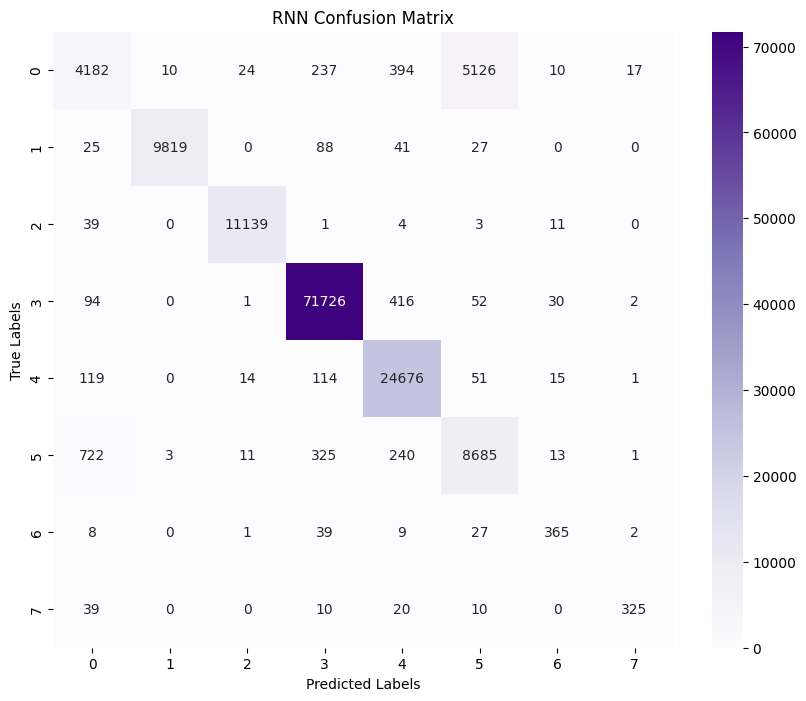

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm_rnn = confusion_matrix(y_test_labels, y_pred_rnn)

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_rnn,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

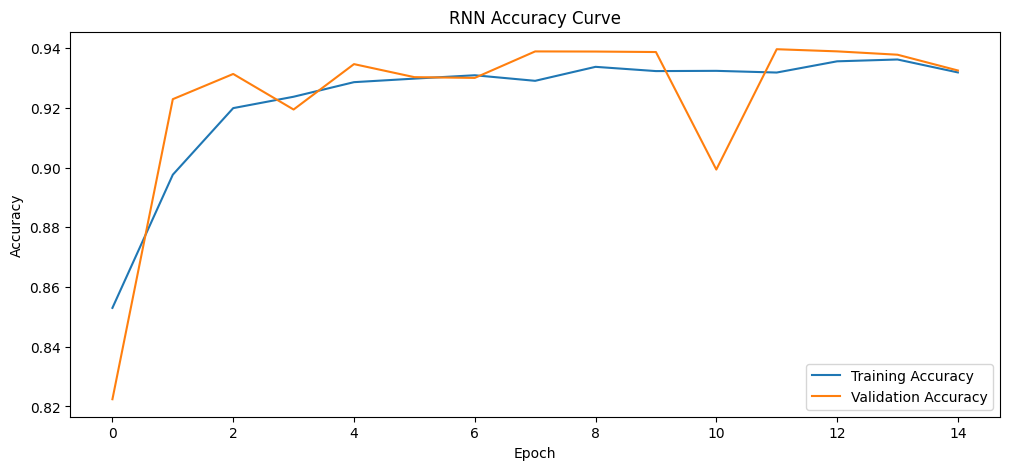

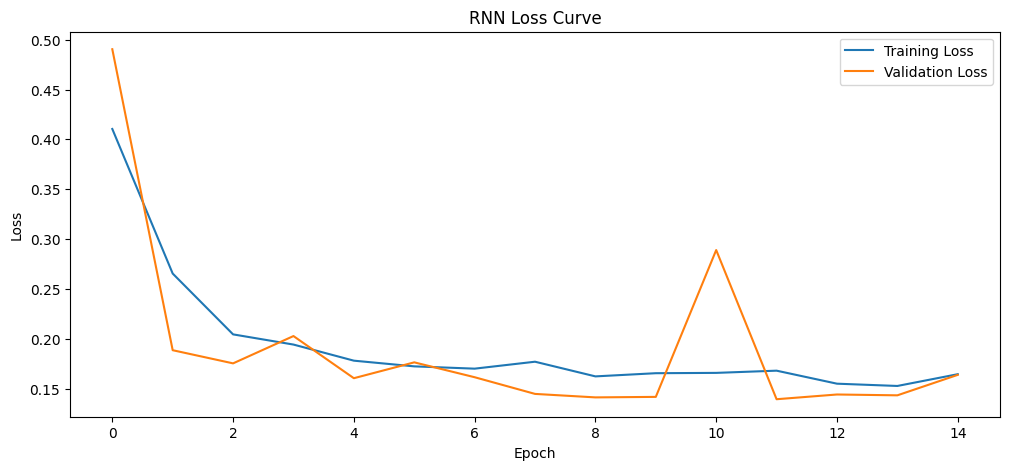

In [29]:
# Accuracy Plot
plt.figure(figsize=(12,5))

plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("RNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(12,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("RNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build LSTM model
lstm_model = Sequential([

    LSTM(
        64,
        input_shape=(57, 1),
        activation='tanh'
    ),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(8, activation='softmax')
])

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Model summary
lstm_model.summary()

# Train model
history_lstm = lstm_model.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,240 (75.16 KB)

 Trainable params: 19,240 (75.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.7994 - loss: 0.5688 - val_accuracy: 0.8253 - val_loss: 0.3767
Epoch 2/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8763 - loss: 0.3095 - val_accuracy: 0.8721 - val_loss: 0.2941
Epoch 3/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8917 - loss: 0.2697 - val_accuracy: 0.9010 - val_loss: 0.2327
Epoch 4/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8946 - loss: 0.2668 - val_accuracy: 0.8974 - val_loss: 0.2543
Epoch 5/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8989 - loss: 0.2508 - val_accuracy: 0.9101 - val_loss: 0.2269
Epoch 6/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9067 - loss: 0.2303 - val_accuracy: 0.9093 - val_loss: 0.2235
Epoch 7/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9175 - loss: 0.2062 - val_accuracy: 0.9271 - val_loss: 0.1794
Epoch 8/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9237 - 

In [32]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred_lstm_probs = lstm_model.predict(X_test_rnn)

# Convert probabilities to class labels
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)

# Convert one-hot labels back to integers
y_test_labels = np.argmax(y_test_rnn, axis=1)

# Accuracy
lstm_accuracy = accuracy_score(y_test_labels, y_pred_lstm)

print("LSTM Accuracy:")
print(lstm_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_lstm))

4356/4356 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step
LSTM Accuracy:
0.9365613541614345

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.43      0.55     10000
           1       0.99      0.98      0.98     10000
           2       0.99      0.99      0.99     11197
           3       0.99      0.99      0.99     72321
           4       0.94      0.99      0.97     24990
           5       0.62      0.84      0.71     10000
           6       0.89      0.74      0.81       451
           7       0.88      0.86      0.87       404

    accuracy                           0.94    139363
   macro avg       0.88      0.85      0.86    139363
weighted avg       0.94      0.94      0.93    139363



In [71]:
# LSTM probability predictions
y_pred_lstm_probs = lstm_model.predict(X_test_rnn)

# ROC-AUC
lstm_roc_auc = roc_auc_score(
    y_test_rnn,
    y_pred_lstm_probs,
    multi_class='ovr'
)

print("LSTM ROC-AUC:")
print(lstm_roc_auc)

4356/4356 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step
LSTM ROC-AUC:
0.9921653573723781


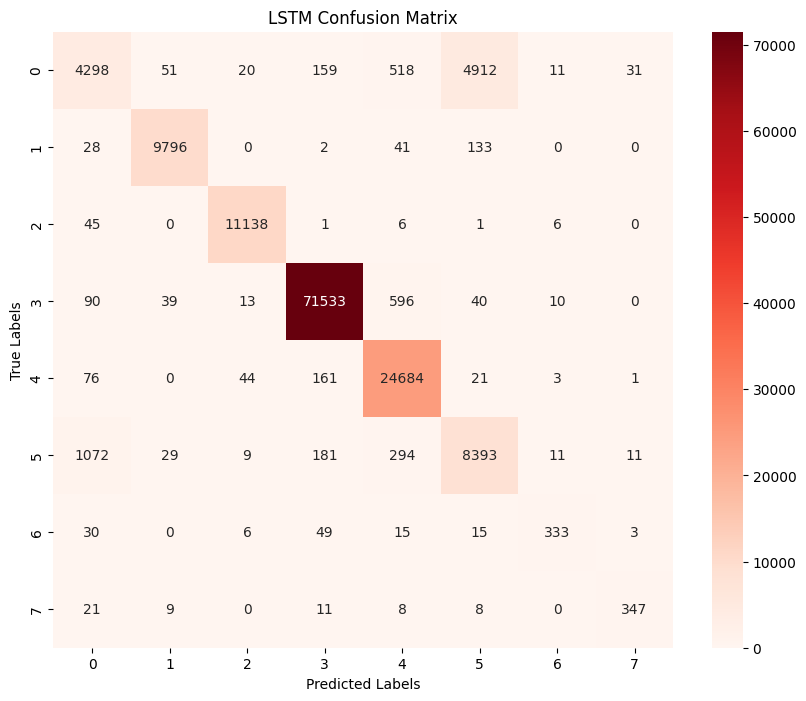

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm_lstm = confusion_matrix(y_test_labels, y_pred_lstm)

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

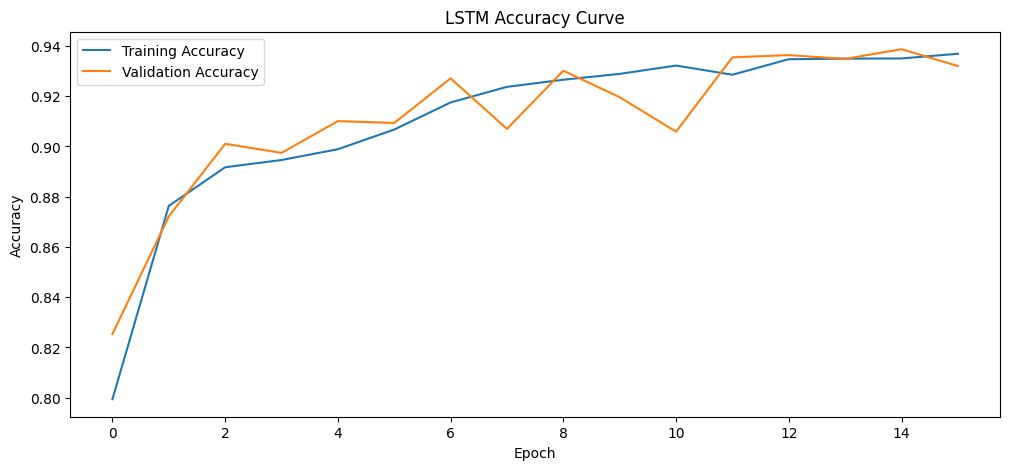

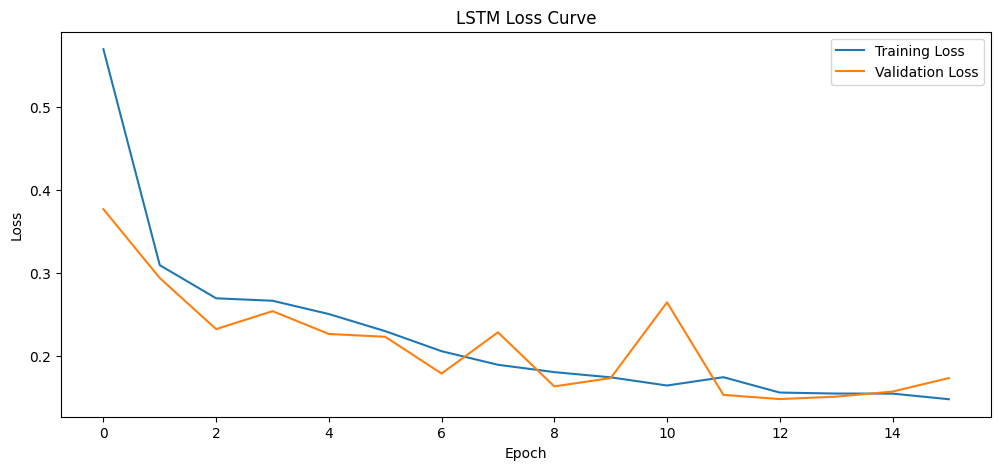

In [34]:
# Accuracy Curve
plt.figure(figsize=(12,5))

plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

# Loss Curve
plt.figure(figsize=(12,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [35]:
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)

from tensorflow.keras.models import Model

In [37]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Input layer
inputs = Input(shape=(57, 1))

# Feature Embedding Projection
x = Dense(64)(inputs)

# Multi-Head Attention
attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=64
)(x, x)

# Residual Connection + Normalization
x = LayerNormalization(epsilon=1e-6)(
    attention_output + x
)

# Feed Forward Network
ffn = Dense(128, activation='relu')(x)
ffn = Dropout(0.3)(ffn)

# Global Pooling
x = GlobalAveragePooling1D()(ffn)

# Dense Layers
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

# Output Layer
outputs = Dense(8, activation='softmax')(x)

# Build Model
transformer_model = Model(inputs=inputs, outputs=outputs)

# Compile
transformer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Summary
transformer_model.summary()

# Train
history_transformer = transformer_model.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop]
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 57, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 57, 64)    │        128 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 57, 64)    │     66,368 │ dense_9[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 57, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 57, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 57, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 57, 128)   │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ dropout_7[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 8)         │        520 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,720 (327.03 KB)

 Trainable params: 83,720 (327.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.8023 - loss: 0.5680 - val_accuracy: 0.8696 - val_loss: 0.3792
Epoch 2/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8594 - loss: 0.3968 - val_accuracy: 0.8706 - val_loss: 0.3357
Epoch 3/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8700 - loss: 0.3560 - val_accuracy: 0.8722 - val_loss: 0.3426
Epoch 4/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8757 - loss: 0.3346 - val_accuracy: 0.8877 - val_loss: 0.2891
Epoch 5/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8811 - loss: 0.3180 - val_accuracy: 0.8851 - val_loss: 0.2874
Epoch 6/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8856 - loss: 0.3042 - val_accuracy: 0.8979 - val_loss: 0.2586
Epoch 7/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8882 - loss: 0.2964 - val_accuracy: 0.8822 - val_loss: 0.3771
Epoch 8/30
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8898 -

In [38]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred_transformer_probs = transformer_model.predict(X_test_rnn)

# Convert probabilities to class labels
y_pred_transformer = np.argmax(y_pred_transformer_probs, axis=1)

# Convert one-hot labels back
y_test_labels = np.argmax(y_test_rnn, axis=1)

# Accuracy
transformer_accuracy = accuracy_score(
    y_test_labels,
    y_pred_transformer
)

print("Transformer Accuracy:")
print(transformer_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test_labels,
    y_pred_transformer
))

4356/4356 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
Transformer Accuracy:
0.9059147693433695

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.27      0.41     10000
           1       0.99      0.98      0.98     10000
           2       0.99      0.99      0.99     11197
           3       0.97      0.98      0.98     72321
           4       0.84      0.96      0.90     24990
           5       0.57      0.75      0.65     10000
           6       0.00      0.00      0.00       451
           7       0.86      0.70      0.77       404

    accuracy                           0.91    139363
   macro avg       0.75      0.70      0.71    139363
weighted avg       0.91      0.91      0.90    139363



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
# Transformer ROC-AUC
transformer_roc_auc = roc_auc_score(
    y_test_rnn,
    y_pred_transformer_probs,
    multi_class='ovr'
)

print("Transformer ROC-AUC:")
print(transformer_roc_auc)

Transformer ROC-AUC:
0.9849509088053519


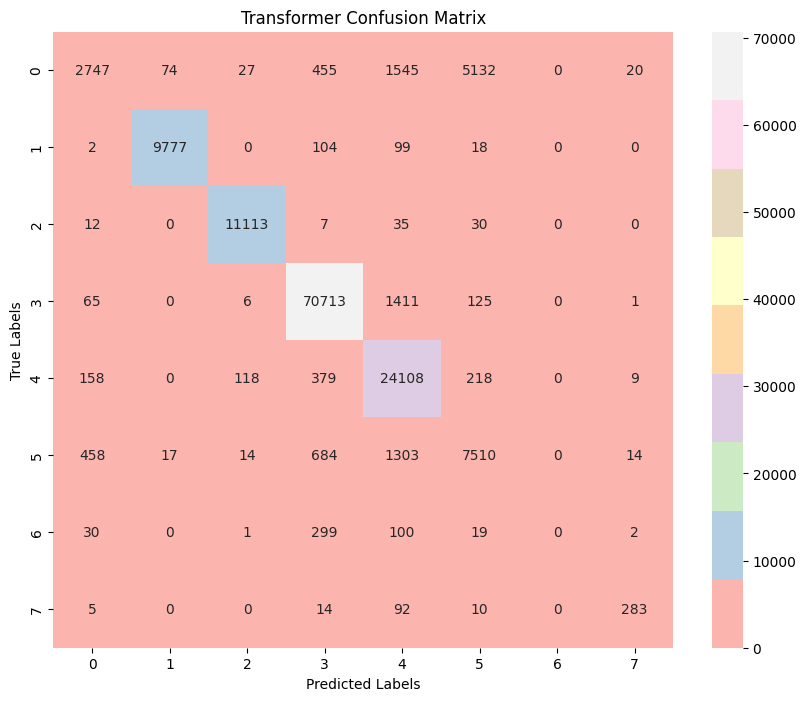

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm_transformer = confusion_matrix(
    y_test_labels,
    y_pred_transformer
)

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_transformer,
    annot=True,
    fmt='d',
    cmap='Pastel1'
)

plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

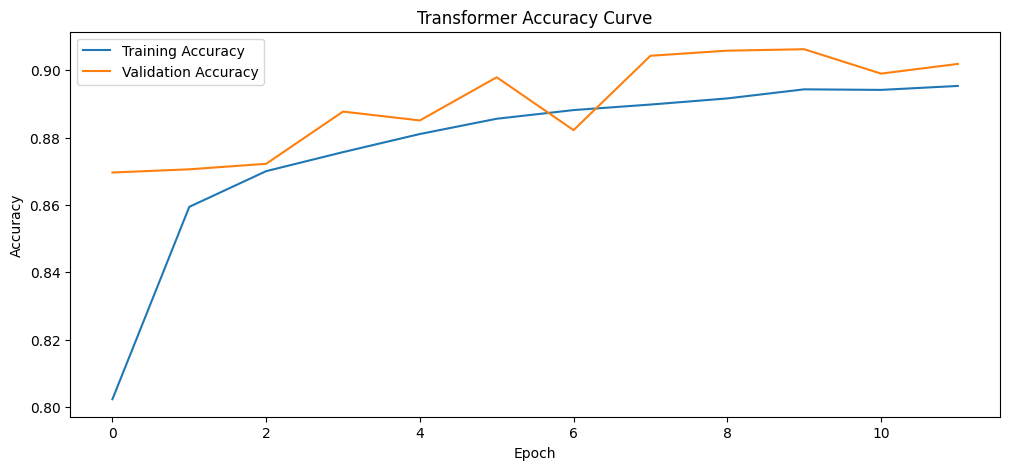

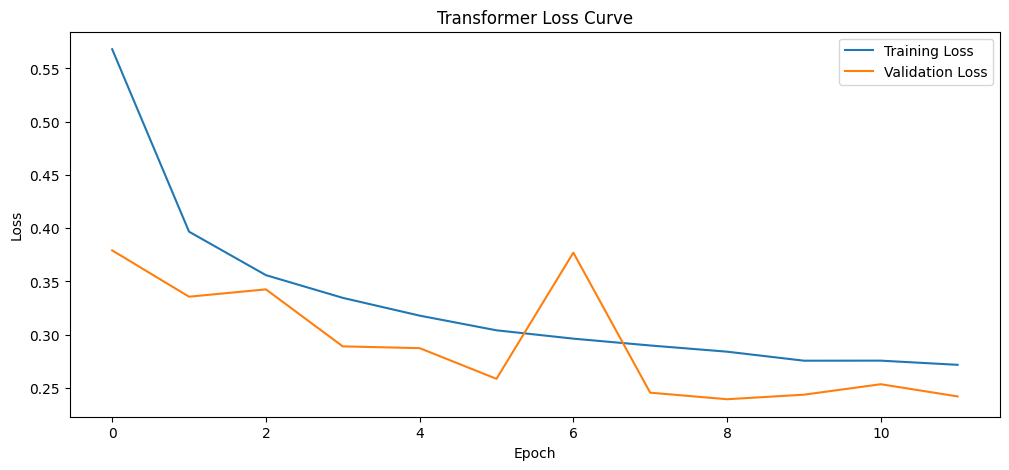

In [60]:
# Accuracy Curve
plt.figure(figsize=(12,5))

plt.plot(history_transformer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transformer.history['val_accuracy'], label='Validation Accuracy')

plt.title("Transformer Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

# Loss Curve
plt.figure(figsize=(12,5))

plt.plot(history_transformer.history['loss'], label='Training Loss')
plt.plot(history_transformer.history['val_loss'], label='Validation Loss')

plt.title("Transformer Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [61]:
!pip install shap

In [62]:
import shap

In [63]:
# Smaller sample for SHAP analysis
X_shap = X_test_scaled[:1000]

print("SHAP Sample Shape:")
print(X_shap.shape)

SHAP Sample Shape:
(1000, 57)


In [64]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP values generated successfully.")

SHAP values generated successfully.


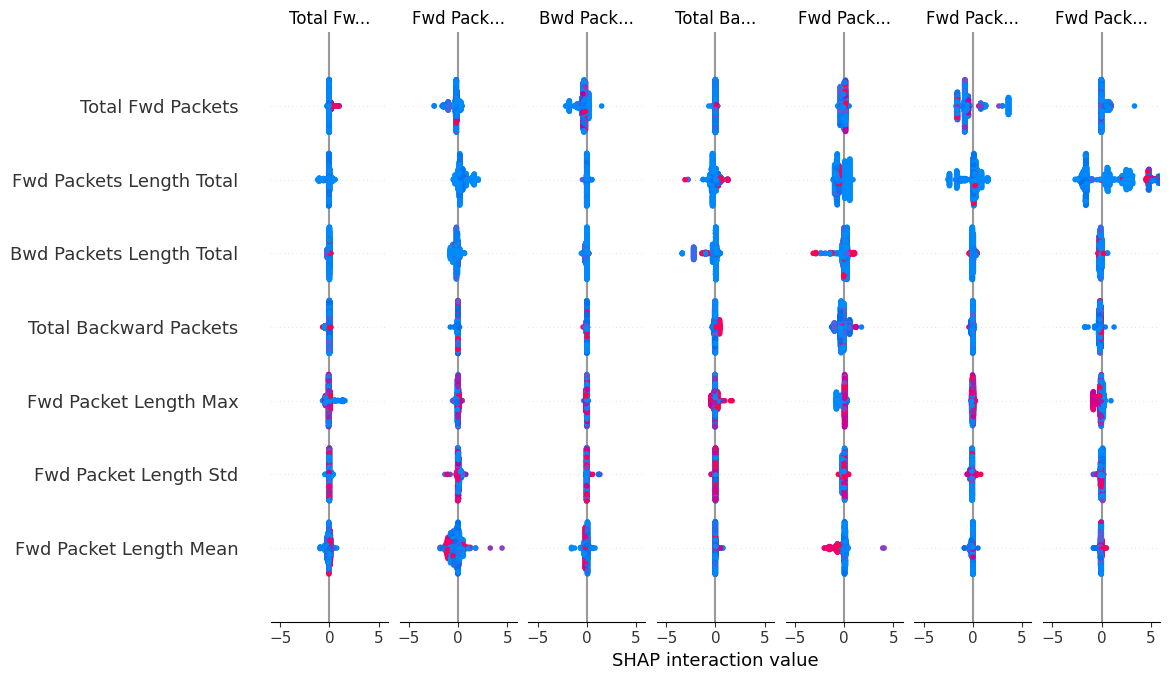

In [65]:
# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns
)

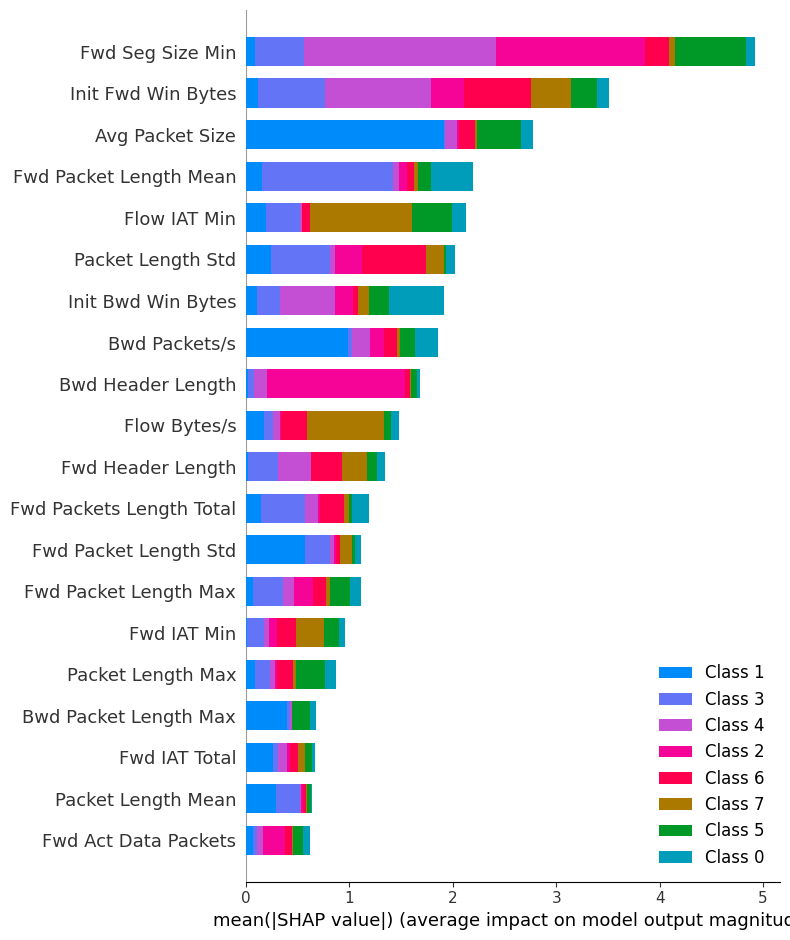

In [66]:
# SHAP Bar Plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns,
    plot_type="bar"
)


FINAL MODEL COMPARISON TABLE:

           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Decision Tree    0.9688       0.93    0.93      0.93   0.9649
1  Random Forest    0.9746       0.95    0.94      0.95   0.9972
2        XGBoost    0.9715       0.95    0.94      0.94   0.9978
3            RNN    0.9394       0.89    0.86      0.86   0.9930
4           LSTM    0.9366       0.88    0.85      0.86   0.9922
5    Transformer    0.9059       0.75    0.70      0.71   0.9850


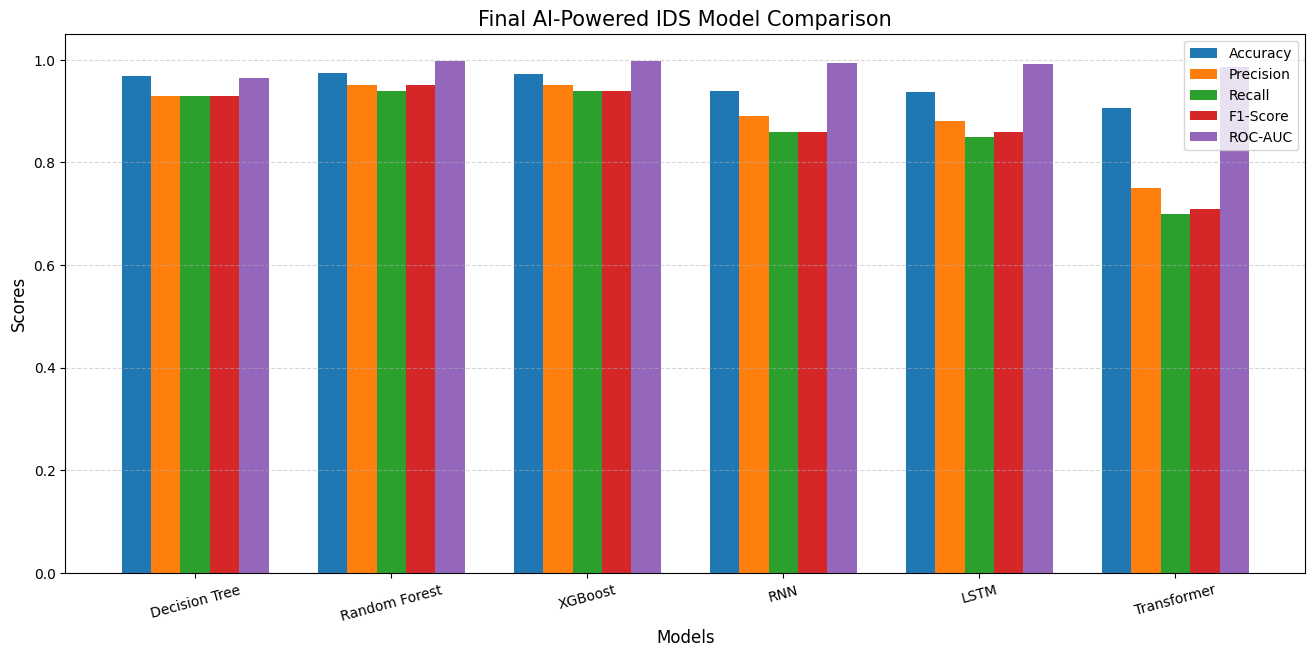

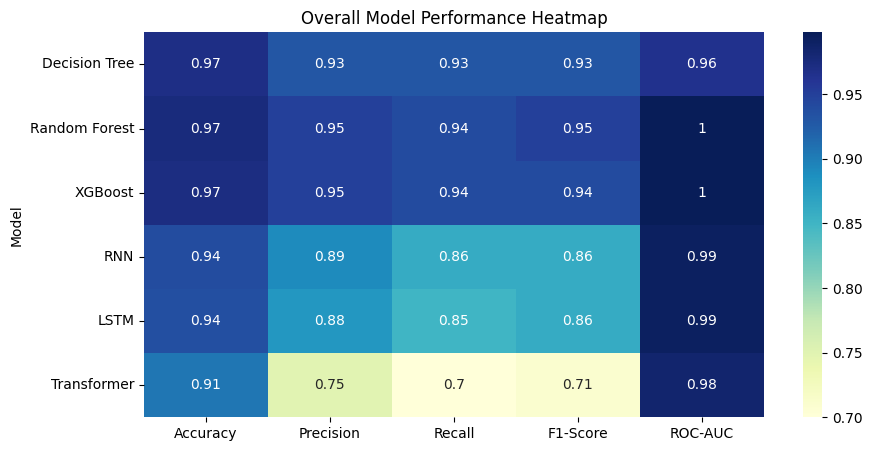


Final comparison table saved successfully.


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# =====================================
# FINAL AUTHENTIC MODEL COMPARISON
# =====================================

comparison_df = pd.DataFrame({

    'Model': [
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'RNN',
        'LSTM',
        'Transformer'
    ],

    'Accuracy': [
        0.9688,
        0.9746,
        0.9715,
        0.9394,
        0.9366,
        0.9059
    ],

    'Precision': [
        0.93,
        0.95,
        0.95,
        0.89,
        0.88,
        0.75
    ],

    'Recall': [
        0.93,
        0.94,
        0.94,
        0.86,
        0.85,
        0.70
    ],

    'F1-Score': [
        0.93,
        0.95,
        0.94,
        0.86,
        0.86,
        0.71
    ],

    'ROC-AUC': [
        0.9649,
        0.9972,
        0.9978,
        0.9930,
        0.9922,
        0.9850
    ]
})

# =====================================
# DISPLAY TABLE
# =====================================

print("\nFINAL MODEL COMPARISON TABLE:\n")
print(comparison_df)

# =====================================
# FINAL COMPARISON GRAPH
# =====================================

metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

models = comparison_df['Model']

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(16,7))

# Plot all metrics
for i, metric in enumerate(metrics):

    plt.bar(
        x + i*width,
        comparison_df[metric],
        width=width,
        label=metric
    )

# Labels
plt.xlabel('Models', fontsize=12)
plt.ylabel('Scores', fontsize=12)

plt.title(
    'Final AI-Powered IDS Model Comparison',
    fontsize=15
)

# X-axis formatting
plt.xticks(
    x + width*2,
    models,
    rotation=15
)

plt.ylim(0, 1.05)

# Legend
plt.legend()

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

# =====================================
# HEATMAP VISUALIZATION
# =====================================

plt.figure(figsize=(10,5))

sns.heatmap(
    comparison_df.set_index('Model'),
    annot=True,
    cmap='YlGnBu'
)

plt.title('Overall Model Performance Heatmap')

plt.show()

# =====================================
# SAVE CSV
# =====================================

comparison_df.to_csv(
    'final_model_comparison.csv',
    index=False
)

print("\nFinal comparison table saved successfully.")